In [1]:
import pandas as pd 
import numpy as np 

In [2]:
# Load the data into a dataframe
df_bookings=pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/fact_bookings.csv')
df_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04- 22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [3]:
df_bookings.shape

(134590, 12)

In [4]:
print(df_bookings['room_category'].unique())
print(df_bookings['booking_platform'].unique())
print(df_bookings['booking_status'].unique())

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str
<StringArray>
[ 'direct online',         'others',        'logtrip',       'tripster',
   'makeyourtrip',        'journey', 'direct offline']
Length: 7, dtype: str
<StringArray>
['Checked Out', 'Cancelled', 'No Show']
Length: 3, dtype: str


In [5]:
df_bookings.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

In [6]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [7]:
df_date = pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/dim_date.csv')
df_date

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday
...,...,...,...,...
87,27-Jul-22,Jul 22,W 31,weekeday
88,28-Jul-22,Jul 22,W 31,weekeday
89,29-Jul-22,Jul 22,W 31,weekeday
90,30-Jul-22,Jul 22,W 31,weekend


In [8]:
df_hotels = pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/dim_hotels.csv')
df_hotels

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi
5,16563,Atliq Palace,Business,Delhi
6,17558,Atliq Grands,Luxury,Mumbai
7,17559,Atliq Exotica,Luxury,Mumbai
8,17560,Atliq City,Business,Mumbai
9,17561,Atliq Blu,Luxury,Mumbai


In [9]:
df_rooms = pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/dim_rooms.csv')
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [10]:
df_agg_bookings = pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/fact_aggregated_bookings.csv')
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0
...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0
9196,16559,31-Jul-22,RT4,13,18.0
9197,17558,31-Jul-22,RT4,3,6.0
9198,19563,31-Jul-22,RT4,3,6.0


In [11]:
df_hotels.shape

(25, 4)

In [12]:
df_hotels.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

In [13]:
df_hotels.city.value_counts().sort_values()

city
Delhi        5
Hyderabad    6
Bangalore    6
Mumbai       8
Name: count, dtype: int64

In [14]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04- 22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [15]:
df_bookings=df_bookings[df_bookings.no_guests>0]

In [16]:
df_bookings[df_bookings.no_guests>0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04- 22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [17]:
df_bookings.shape

(134578, 12)

In [18]:
df_bookings['revenue_generated'].min()

6500

In [19]:
df_bookings['revenue_generated'].max()

28560000

In [20]:
avg = df_bookings['revenue_generated'].mean()

In [21]:
std = df_bookings['revenue_generated'].std()

In [22]:
lower_limit = avg-(3*std)
higher_limit = avg+(3*std)

In [23]:
df_bookings[df_bookings.revenue_generated>higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04- 22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [24]:
df_bookings = df_bookings[df_bookings.revenue_generated<higher_limit]

In [25]:
df_bookings 

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [26]:
df_bookings.shape

(134573, 12)

In [27]:
df_bookings.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [28]:
df_bookings['revenue_realized'].describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [29]:
upper = df_bookings['revenue_realized'].mean() + (3*(df_bookings['revenue_realized'].std()))

In [30]:
upper

33479.358661845814

In [31]:
lower = df_bookings['revenue_realized'].mean() - (3*(df_bookings['revenue_realized'].std()))
lower

-8087.391491611072

In [32]:
kuchbhi= df_bookings[df_bookings['revenue_realized']>upper]
kuchbhi

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


In [33]:
expensive_shit = df_bookings[df_bookings['room_category']=='RT4']
expensive_shit.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,16071.000000,16071.000000,6879.000000,16071.000000,16071.000000
mean,18031.070437,2.105283,3.687164,27465.457034,23439.308444
std,1034.119639,1.207111,1.266633,6310.403418,9048.599076
min,16558.000000,1.000000,1.000000,19000.000000,7600.000000
25%,17559.000000,1.000000,3.000000,19000.000000,19000.000000
50%,18558.000000,2.000000,4.000000,28500.000000,26600.000000
75%,18562.000000,2.000000,5.000000,32300.000000,32300.000000
max,19563.000000,6.000000,5.000000,45220.000000,45220.000000


In [34]:
very_expensive=expensive_shit['revenue_realized'].mean()+3*expensive_shit['revenue_realized'].std()
very_expensive

50585.10567100048

In [35]:
df_bookings[df_bookings['revenue_realized']>very_expensive]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [36]:
kuchbhi[kuchbhi['room_category']=='RT4']

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


In [37]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [38]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


In [39]:
df_agg_bookings['occupancy_percentage']=df_agg_bookings['successful_bookings']/df_agg_bookings['capacity']

In [40]:
df_agg_bookings.rename(columns = {
    'occupance_percentage':'occupancy_percentage'
})

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
3,17558,1-May-22,RT1,30,19.0,1.578947
4,16558,1-May-22,RT1,18,19.0,0.947368
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,0.722222
9196,16559,31-Jul-22,RT4,13,18.0,0.722222
9197,17558,31-Jul-22,RT4,3,6.0,0.500000
9198,19563,31-Jul-22,RT4,3,6.0,0.500000


In [41]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
3,17558,1-May-22,RT1,30,19.0,1.578947
4,16558,1-May-22,RT1,18,19.0,0.947368
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,0.722222
9196,16559,31-Jul-22,RT4,13,18.0,0.722222
9197,17558,31-Jul-22,RT4,3,6.0,0.500000
9198,19563,31-Jul-22,RT4,3,6.0,0.500000


In [42]:
df_agg_bookings['occupancy_percentage']=df_agg_bookings['occupancy_percentage'].apply(lambda x : x*100)

In [43]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage
0,16559,1-May-22,RT1,25,30.0,83.333333
1,19562,1-May-22,RT1,28,30.0,93.333333
2,19563,1-May-22,RT1,23,30.0,76.666667
3,17558,1-May-22,RT1,30,19.0,157.894737
4,16558,1-May-22,RT1,18,19.0,94.736842
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.222222
9196,16559,31-Jul-22,RT4,13,18.0,72.222222
9197,17558,31-Jul-22,RT4,3,6.0,50.000000
9198,19563,31-Jul-22,RT4,3,6.0,50.000000


In [44]:
df_agg_bookings['occupancy_percentage']=df_agg_bookings['occupancy_percentage'].apply(lambda x : round(x,2))

In [45]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
3,17558,1-May-22,RT1,30,19.0,157.89
4,16558,1-May-22,RT1,18,19.0,94.74
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.22
9196,16559,31-Jul-22,RT4,13,18.0,72.22
9197,17558,31-Jul-22,RT4,3,6.0,50.00
9198,19563,31-Jul-22,RT4,3,6.0,50.00


In [50]:
df1 = df_agg_bookings.groupby('room_category')['occupancy_percentage'].mean().round(2)

In [56]:
final = pd.merge(df1,df_rooms,left_on='room_category',right_on = 'room_id')

In [57]:
final[['room_class','occupancy_percentage']]

,room_class,occupancy_percentage
0,Standard,58.22
1,Elite,58.04
2,Premium,58.03
3,Presidential,59.30


In [58]:
df1

room_category
RT1    58.22
RT2    58.04
RT3    58.03
RT4    59.30
Name: occupancy_percentage, dtype: float64

In [59]:
df2 = pd.merge(df_agg_bookings,df_hotels,on='property_id',how = 'inner')
df2

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,83.33,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,93.33,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,23,30.0,76.67,Atliq Palace,Business,Bangalore
3,17558,1-May-22,RT1,30,19.0,157.89,Atliq Grands,Luxury,Mumbai
4,16558,1-May-22,RT1,18,19.0,94.74,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.22,Atliq Palace,Business,Delhi
9196,16559,31-Jul-22,RT4,13,18.0,72.22,Atliq Exotica,Luxury,Mumbai
9197,17558,31-Jul-22,RT4,3,6.0,50.00,Atliq Grands,Luxury,Mumbai
9198,19563,31-Jul-22,RT4,3,6.0,50.00,Atliq Palace,Business,Bangalore


<Axes: xlabel='city'>

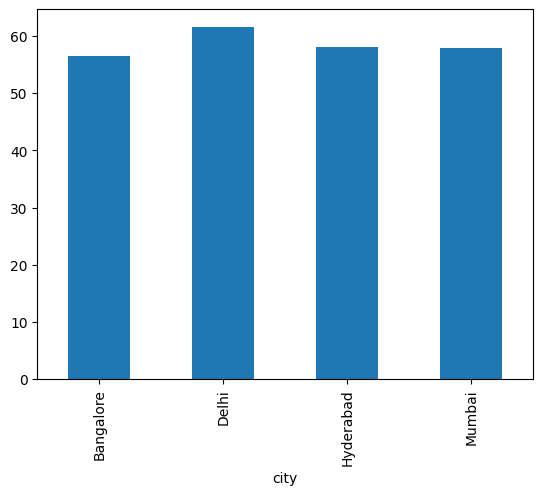

In [62]:
df3 = df2.groupby('city')['occupancy_percentage'].mean().plot(kind = 'bar')
df3

In [66]:
df4 = pd.merge(df2,df_date,left_on = 'check_in_date',right_on = 'date')
df5 = df4.groupby('day_type')['occupancy_percentage'].mean().round(2)
df5

day_type
weekeday    50.90
weekend     72.39
Name: occupancy_percentage, dtype: float64

In [75]:
df6=df4[df4['mmm yy']=='Jun 22']
df6.groupby('city')['occupancy_percentage'].mean().round(2).sort_values(ascending = False)

city
Delhi        62.47
Hyderabad    58.46
Mumbai       58.38
Bangalore    56.58
Name: occupancy_percentage, dtype: float64

In [76]:
df_august = pd.read_csv('/Users/pranavaditya/Desktop/Data-Engineering-Journey/Projects/Hospitality_Data Analyst/new_data_august.csv')
df_august

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92
5,17561,Atliq Blu,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,18,26,69.23
6,17564,Atliq Seasons,Business,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,10,16,62.50


In [79]:
latest = pd.concat([df4,df_august],ignore_index=True,axis=0)

In [81]:
df4.shape

(6500, 13)

In [82]:
df_august.shape

(7, 13)

In [84]:
latest

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,property_name,category,city,date,mmm yy,week no,day_type,room_class,occ%
0,19563,10-May-22,RT3,15,29.0,51.72,Atliq Palace,Business,Bangalore,10-May-22,May 22,W 20,weekeday,NaN,NaN
1,18560,10-May-22,RT1,19,30.0,63.33,Atliq City,Business,Hyderabad,10-May-22,May 22,W 20,weekeday,NaN,NaN
2,19562,10-May-22,RT1,18,30.0,60.00,Atliq Bay,Luxury,Bangalore,10-May-22,May 22,W 20,weekeday,NaN,NaN
3,19563,10-May-22,RT1,16,30.0,53.33,Atliq Palace,Business,Bangalore,10-May-22,May 22,W 20,weekeday,NaN,NaN
4,17558,10-May-22,RT1,11,19.0,57.89,Atliq Grands,Luxury,Mumbai,10-May-22,May 22,W 20,weekeday,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,19563,01-Aug-22,RT1,23,30.0,NaN,Atliq Palace,Business,Bangalore,NaN,Aug-22,W 32,weekeday,Standard,76.67
6503,19558,01-Aug-22,RT1,30,40.0,NaN,Atliq Grands,Luxury,Bangalore,NaN,Aug-22,W 32,weekeday,Standard,75.00
6504,19560,01-Aug-22,RT1,20,26.0,NaN,Atliq City,Business,Bangalore,NaN,Aug-22,W 32,weekeday,Standard,76.92
6505,17561,01-Aug-22,RT1,18,26.0,NaN,Atliq Blu,Luxury,Mumbai,NaN,Aug-22,W 32,weekeday,Standard,69.23


In [83]:
latest.shape

(6507, 15)

In [88]:
merged = pd.merge(df_bookings,df_hotels,on ='property_id',how = 'inner')
merged.groupby('city')['revenue_realized'].sum()

city
Bangalore    420383550
Delhi        294404488
Hyderabad    325179310
Mumbai       668569251
Name: revenue_realized, dtype: int64

In [89]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [95]:
df_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [91]:
df_date.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      92 non-null     str  
 1   mmm yy    92 non-null     str  
 2   week no   92 non-null     str  
 3   day_type  92 non-null     str  
dtypes: str(4)
memory usage: 3.0 KB


In [92]:
df_bookings.info()

<class 'pandas.DataFrame'>
Index: 134573 entries, 1 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134573 non-null  str    
 1   property_id        134573 non-null  int64  
 2   booking_date       134573 non-null  str    
 3   check_in_date      134573 non-null  str    
 4   checkout_date      134573 non-null  str    
 5   no_guests          134573 non-null  float64
 6   room_category      134573 non-null  str    
 7   booking_platform   134573 non-null  str    
 8   ratings_given      56676 non-null   float64
 9   booking_status     134573 non-null  str    
 10  revenue_generated  134573 non-null  int64  
 11  revenue_realized   134573 non-null  int64  
dtypes: float64(2), int64(3), str(7)
memory usage: 13.3 MB


In [93]:
pd.merge(df_bookings,df_date,left_on='check_in_date',right_on='date')

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,date,mmm yy,week no,day_type


In [96]:
df_bookings["check_in_date"].unique()

<StringArray>
[ '1/5/2022',  '2/5/2022',  '3/5/2022',  '4/5/2022',  '5/5/2022',  '6/5/2022',
  '7/5/2022',  '8/5/2022',  '9/5/2022', '10/5/2022', '11/5/2022', '12/5/2022',
  '13-05-22',  '14-05-22',  '15-05-22',  '16-05-22',  '17-05-22',  '18-05-22',
  '19-05-22',  '20-05-22',  '21-05-22',  '22-05-22',  '23-05-22',  '24-05-22',
  '25-05-22',  '26-05-22',  '27-05-22',  '28-05-22',  '29-05-22',  '30-05-22',
  '31-05-22',  '1/6/2022',  '2/6/2022',  '3/6/2022',  '4/6/2022',  '5/6/2022',
  '6/6/2022',  '7/6/2022',  '8/6/2022',  '9/6/2022', '10/6/2022', '11/6/2022',
 '12/6/2022',  '13-06-22',  '14-06-22',  '15-06-22',  '16-06-22',  '17-06-22',
  '18-06-22',  '19-06-22',  '20-06-22',  '21-06-22',  '22-06-22',  '23-06-22',
  '24-06-22',  '25-06-22',  '26-06-22',  '27-06-22',  '28-06-22',  '29-06-22',
  '30-06-22',  '1/7/2022',  '2/7/2022',  '3/7/2022',  '4/7/2022',  '5/7/2022',
  '6/7/2022',  '7/7/2022',  '8/7/2022',  '9/7/2022', '10/7/2022', '11/7/2022',
 '12/7/2022',  '13-07-22',  '14-07-22'

In [97]:
import pandas as pd
print(pd.__version__)

3.0.3


In [99]:
df_bookings["check_in_date"] = pd.to_datetime(
    df_bookings["check_in_date"],
    format="mixed",
    dayfirst=True
)

In [100]:
df_bookings['check_in_date'].unique()

<DatetimeArray>
['2022-05-01 00:00:00', '2022-05-02 00:00:00', '2022-05-03 00:00:00',
 '2022-05-04 00:00:00', '2022-05-05 00:00:00', '2022-05-06 00:00:00',
 '2022-05-07 00:00:00', '2022-05-08 00:00:00', '2022-05-09 00:00:00',
 '2022-05-10 00:00:00', '2022-05-11 00:00:00', '2022-05-12 00:00:00',
 '2022-05-13 00:00:00', '2022-05-14 00:00:00', '2022-05-15 00:00:00',
 '2022-05-16 00:00:00', '2022-05-17 00:00:00', '2022-05-18 00:00:00',
 '2022-05-19 00:00:00', '2022-05-20 00:00:00', '2022-05-21 00:00:00',
 '2022-05-22 00:00:00', '2022-05-23 00:00:00', '2022-05-24 00:00:00',
 '2022-05-25 00:00:00', '2022-05-26 00:00:00', '2022-05-27 00:00:00',
 '2022-05-28 00:00:00', '2022-05-29 00:00:00', '2022-05-30 00:00:00',
 '2022-05-31 00:00:00', '2022-06-01 00:00:00', '2022-06-02 00:00:00',
 '2022-06-03 00:00:00', '2022-06-04 00:00:00', '2022-06-05 00:00:00',
 '2022-06-06 00:00:00', '2022-06-07 00:00:00', '2022-06-08 00:00:00',
 '2022-06-09 00:00:00', '2022-06-10 00:00:00', '2022-06-11 00:00:00',
 '20

In [101]:
df_date['date']=pd.to_datetime(df_date['date'])
df_date

/var/folders/_6/1zrsbpxj2mj9fwqzg1q903980000gn/T/ipykernel_2265/2458064437.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_date['date']=pd.to_datetime(df_date['date'])


,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday
3,2022-05-04,May 22,W 19,weekeday
4,2022-05-05,May 22,W 19,weekeday
...,...,...,...,...
87,2022-07-27,Jul 22,W 31,weekeday
88,2022-07-28,Jul 22,W 31,weekeday
89,2022-07-29,Jul 22,W 31,weekeday
90,2022-07-30,Jul 22,W 31,weekend


In [102]:
df_date['date'].dtype

dtype('<M8[us]')

In [103]:
df_date.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      92 non-null     datetime64[us]
 1   mmm yy    92 non-null     str           
 2   week no   92 non-null     str           
 3   day_type  92 non-null     str           
dtypes: datetime64[us](1), str(3)
memory usage: 3.0 KB


In [106]:
final_merged = pd.merge(df_bookings , df_date,left_on = df_bookings['check_in_date'],right_on = df_date['date'])

In [108]:
results = final_merged.groupby('mmm yy')['revenue_realized'].sum()

In [109]:
results

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

In [110]:
final_merged

,key_0,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,date,mmm yy,week no,day_type
0,2022-05-01,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,2022-05-01,May 22,W 19,weekend
1,2022-05-01,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,2022-05-01,May 22,W 19,weekend
2,2022-05-01,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,2022-05-01,May 22,W 19,weekend
3,2022-05-01,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,2022-05-01,May 22,W 19,weekend
4,2022-05-01,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,2022-05-01,May 22,W 19,weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,2022-07-31,Jul312217564RT45,17564,30-07-22,2022-07-31,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend
134569,2022-07-31,Jul312217564RT46,17564,29-07-22,2022-07-31,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend
134570,2022-07-31,Jul312217564RT48,17564,30-07-22,2022-07-31,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,2022-07-31,Jul 22,W 32,weekend
134571,2022-07-31,Jul312217564RT49,17564,29-07-22,2022-07-31,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend


In [113]:
uff = pd.merge(final_merged,df_rooms,left_on ='room_category',right_on = 'room_id')
uff1=pd.merge(uff,df_hotels,on = 'property_id')
uff1

,key_0,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,...,revenue_realized,date,mmm yy,week no,day_type,room_id,room_class,property_name,category,city
0,2022-05-01,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,...,3640,2022-05-01,May 22,W 19,weekend,RT1,Standard,Atliq Grands,Luxury,Delhi
1,2022-05-01,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,...,10920,2022-05-01,May 22,W 19,weekend,RT1,Standard,Atliq Grands,Luxury,Delhi
2,2022-05-01,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,...,9100,2022-05-01,May 22,W 19,weekend,RT1,Standard,Atliq Grands,Luxury,Delhi
3,2022-05-01,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,...,3640,2022-05-01,May 22,W 19,weekend,RT1,Standard,Atliq Grands,Luxury,Delhi
4,2022-05-01,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,...,9100,2022-05-01,May 22,W 19,weekend,RT1,Standard,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,2022-07-31,Jul312217564RT45,17564,30-07-22,2022-07-31,1/8/2022,2.0,RT4,others,2.0,...,32300,2022-07-31,Jul 22,W 32,weekend,RT4,Presidential,Atliq Seasons,Business,Mumbai
134569,2022-07-31,Jul312217564RT46,17564,29-07-22,2022-07-31,3/8/2022,1.0,RT4,makeyourtrip,2.0,...,32300,2022-07-31,Jul 22,W 32,weekend,RT4,Presidential,Atliq Seasons,Business,Mumbai
134570,2022-07-31,Jul312217564RT48,17564,30-07-22,2022-07-31,2/8/2022,1.0,RT4,tripster,NaN,...,12920,2022-07-31,Jul 22,W 32,weekend,RT4,Presidential,Atliq Seasons,Business,Mumbai
134571,2022-07-31,Jul312217564RT49,17564,29-07-22,2022-07-31,1/8/2022,2.0,RT4,logtrip,2.0,...,32300,2022-07-31,Jul 22,W 32,weekend,RT4,Presidential,Atliq Seasons,Business,Mumbai


In [116]:
result1 = uff1.groupby('category')['revenue_realized'].sum()
result1

category
Business     655967037
Luxury      1052569562
Name: revenue_realized, dtype: int64

In [118]:
result2 = uff1.groupby('city')['ratings_given'].mean()
result2

city
Bangalore    3.407681
Delhi        3.779298
Hyderabad    3.661041
Mumbai       3.650545
Name: ratings_given, dtype: float64

<Axes: >

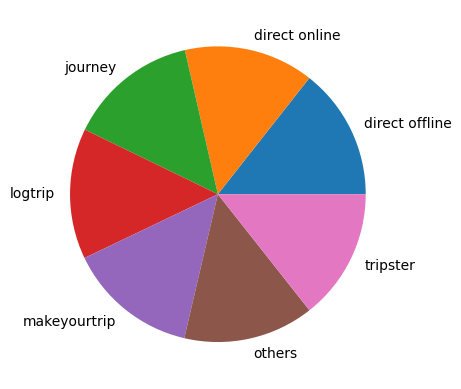

In [123]:
result3 = uff1.groupby('booking_platform')['revenue_realized'].mean().plot(kind = "pie")
result3